In [1]:
%cd ..
%env
%load_ext autoreload
%autoreload 2

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

from src.datasets.visloc import SatChunkDataset, UAVDataset
from src.evaluation import build_ground_truth, calculate_metrics
from src.retrievers import FAISSRetriever
from src.utils import visualize_embeddings

warnings.filterwarnings("ignore", message=".*invalid escape sequence.*")

NUM_WORKERS = 8
DEVICE = torch.device("cuda")
# DTYPE = torch.bfloat16
VISLOC_ROOT = Path(os.environ["VISLOC_ROOT"])
DIFFUSIONSAT_256_CHCKPT = Path(os.environ["DIFFUSIONSAT_256_CHCKPT"])

/root/diffusion-vpr/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/root/diffusion-vpr


In [6]:
from src.backbones.dift import SDFeaturizer

dift = SDFeaturizer(null_prompt="a satellite image")

In [48]:
# TIMESTEP = 261
# TIMESTEP = 1000 - 261
TIMESTEP = 120
UP_FT_INDEX = 1
ENSEMBLE_SIZE = 1


@torch.inference_mode()
def extract_embeddings(loader: DataLoader) -> tuple[torch.Tensor, list[float], list[float]]:
  embeddings = []
  all_lats = []
  all_lons = []

  for imgs, lats, lons in tqdm(loader, desc="Building embeddings"):
    imgs = imgs.to(DEVICE)
    embs = dift.forward(
      img_tensor=imgs,
      t=TIMESTEP,
      up_ft_index=UP_FT_INDEX,
      ensemble_size=ENSEMBLE_SIZE,
    )

    embeddings.append(embs.cpu())
    all_lats.extend(lats)
    all_lons.extend(lons)

  embeddings = torch.cat(embeddings, dim=0)
  embeddings = F.normalize(embeddings, p=2, dim=1)

  return embeddings, all_lats, all_lons

In [49]:
import cv2
from PIL import Image

BATCH_SIZE = 8

FLIGHT_ID = "03"

CHUNK_PIXELS = 512
CHUNK_STRIDE = CHUNK_PIXELS // 4
MAP_SCALE_FACTOR = 0.25


def t_canny(img: Image.Image):
  c = cv2.Canny(np.array(img).astype(np.uint8), threshold1=100, threshold2=200, apertureSize=3, L2gradient=False)
  pil_image = Image.fromarray(c).convert("RGB")
  return pil_image


inference_sat_transforms = transforms.Compose(
  [
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)
inference_uav_transforms = transforms.Compose(
  [
    transforms.Resize(512),
    transforms.CenterCrop((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)


gallery_dataset = SatChunkDataset(
  VISLOC_ROOT,
  FLIGHT_ID,
  chunk_pixels=CHUNK_PIXELS,
  stride_pixels=CHUNK_STRIDE,
  scale_factor=MAP_SCALE_FACTOR,
  transform=inference_sat_transforms,
)
gallery_loader = DataLoader(
  gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

uav_dataset = UAVDataset(VISLOC_ROOT, FLIGHT_ID, transform=inference_uav_transforms)
uav_loader = DataLoader(uav_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Gallery: {len(gallery_dataset)} satellite chunks")
print(f"Query:   {len(uav_dataset)} UAV images")

Gallery: 2860 satellite chunks
Query:   768 UAV images


In [50]:
gallery_embeddings, _, _ = extract_embeddings(gallery_loader)
query_embeddings, uav_lats, uav_lons = extract_embeddings(uav_loader)

Building embeddings:   0%|          | 0/358 [00:00<?, ?it/s]

Building embeddings: 100%|██████████| 96/96 [00:35<00:00,  2.71it/s]


In [52]:
def gem_pool(x: torch.Tensor, p: float = 3.0, eps: float = 1e-6) -> torch.Tensor:
  """Generalised mean pooling (https://arxiv.org/abs/1711.02512)."""
  return F.avg_pool2d(x.float().clamp(min=eps).pow(p), (x.size(-2), x.size(-1))).pow(1.0 / p).flatten(1)


# FIXME: GeM pooling loves large p???

g = gem_pool(gallery_embeddings, p=3)
q = gem_pool(query_embeddings, p=3)

uav_coords = np.stack([uav_lats, uav_lons], axis=1)
ground_truth = build_ground_truth(uav_coords, gallery_dataset.chunk_bboxes)

print(f"{len(ground_truth)} UAV queries, avg {np.mean([len(gt) for gt in ground_truth]):.1f} matching chunks each")

retriever = FAISSRetriever(g)
distances, preds = retriever.search(q, k=10)

metrics = calculate_metrics(preds, ground_truth)

print(metrics)

768 UAV queries, avg 15.9 matching chunks each
{'Recall@1': 0.0, 'Recall@5': 0.0013020833333333333, 'Recall@10': 0.0078125}


In [53]:
import torch
import torch.nn.functional as F
from tqdm import tqdm


def dift_retrieval(
  query_feats: torch.Tensor,  # [M, C, H, W]
  gallery_feats: torch.Tensor,  # [N, C, H, W]
  gallery_batch_size: int = 1024,
  device: str = "cuda",
) -> torch.Tensor:
  """
  For each query location, find its best-matching location in each gallery
  image (nearest neighbour in feature space), then average those max cosine
  similarities as the image-level score.

  Returns: similarity matrix [M, N], higher = more similar.
  """
  M = query_feats.shape[0]
  N = gallery_feats.shape[0]

  # Normalise across the channel dim at every spatial location
  # so dot-product == cosine similarity
  q = F.normalize(query_feats.flatten(2), dim=1)  # [M, C, HW_q]
  g = F.normalize(gallery_feats.flatten(2), dim=1)  # [N, C, HW_g]
  g = g.to(device)

  scores = torch.zeros(M, N)

  for i in tqdm(range(M), desc="DIFT retrieval"):
    q_i = q[i].to(device)  # [C, HW_q]

    for j in range(0, N, gallery_batch_size):
      g_batch = g[j : j + gallery_batch_size]  # [B, C, HW_g]

      # corr[b, p, r] = cosine_sim(q_i[:, p], g_batch[b, :, r])
      # shape: [B, HW_q, HW_g]
      corr = torch.einsum("cp,bcr->bpr", q_i, g_batch)

      # For each query location p, take the best-matching gallery location
      # then average over all query locations → scalar score per gallery image
      score = corr.max(dim=2).values.mean(dim=1)  # [B]
      scores[i, j : j + gallery_batch_size] = score.cpu()

  return scores  # [M, N]


sim = dift_retrieval(query_embeddings, gallery_embeddings)

# sort descending → ranked list of gallery indices per query
preds = sim.argsort(dim=1, descending=True).numpy()  # [M, N]

metrics = calculate_metrics(preds, ground_truth)
print(metrics)

DIFT retrieval: 100%|██████████| 768/768 [05:33<00:00,  2.30it/s]


{'Recall@1': 0.01171875, 'Recall@5': 0.026041666666666668, 'Recall@10': 0.045572916666666664}


In [ ]:
entry = {
  "model": "stable-diffusion-2-1-dift",
  "model_extra": {
    "timestep": TIMESTEP,
    "up_ft_index": UP_FT_INDEX,
    "ensemble_size": ENSEMBLE_SIZE,
  },
  "dataset": "visloc",
  "dataset_extra": {
    "flight_id": FLIGHT_ID,
    "chunk_pixels": CHUNK_PIXELS,
    "chunk_stride": CHUNK_STRIDE,
    "map_scale_factor": MAP_SCALE_FACTOR,
  },
  "emb_dim": gallery_embeddings.shape[1],
  "n_gallery": len(gallery_dataset),
  "n_query": len(uav_dataset),
  "retriever_type": retriever.type,
  **metrics,
}

entry

{'model': 'diffusionsat',
 'model_extra': {'note': 'canny-preprocessing',
  'embedder': 'PoolConcatEmbedder',
  'img_size': 256,
  'batch_size': 256,
  'save_timesteps': [8, 7],
  'num_timesteps': 10,
  'layer_idxs': {'down_blocks': {'attn1': 'all'}},
  'diffusion_mode': 'inversion',
  'prompt': 'A satellite image',
  'negative_prompt': '',
  'resize_outputs': -1,
  'max_i': None,
  'min_i': None},
 'dataset': 'visloc',
 'dataset_extra': {'flight_id': '03',
  'chunk_pixels': 512,
  'chunk_stride': 128,
  'map_scale_factor': 0.25},
 'emb_dim': 8960,
 'n_gallery': 2860,
 'n_query': 768,
 'retriever_type': 'ip',
 'Recall@1': 0.0,
 'Recall@5': 0.0026041666666666665,
 'Recall@10': 0.005208333333333333}

In [8]:
results_path = Path("results/1-baseline-comparison.csv")
results = pd.read_csv(results_path).to_dict(orient="records") if results_path.exists() else []

results.append(entry)

pd.DataFrame(results).sort_values("Recall@1", ascending=False).to_csv(results_path, index=False)


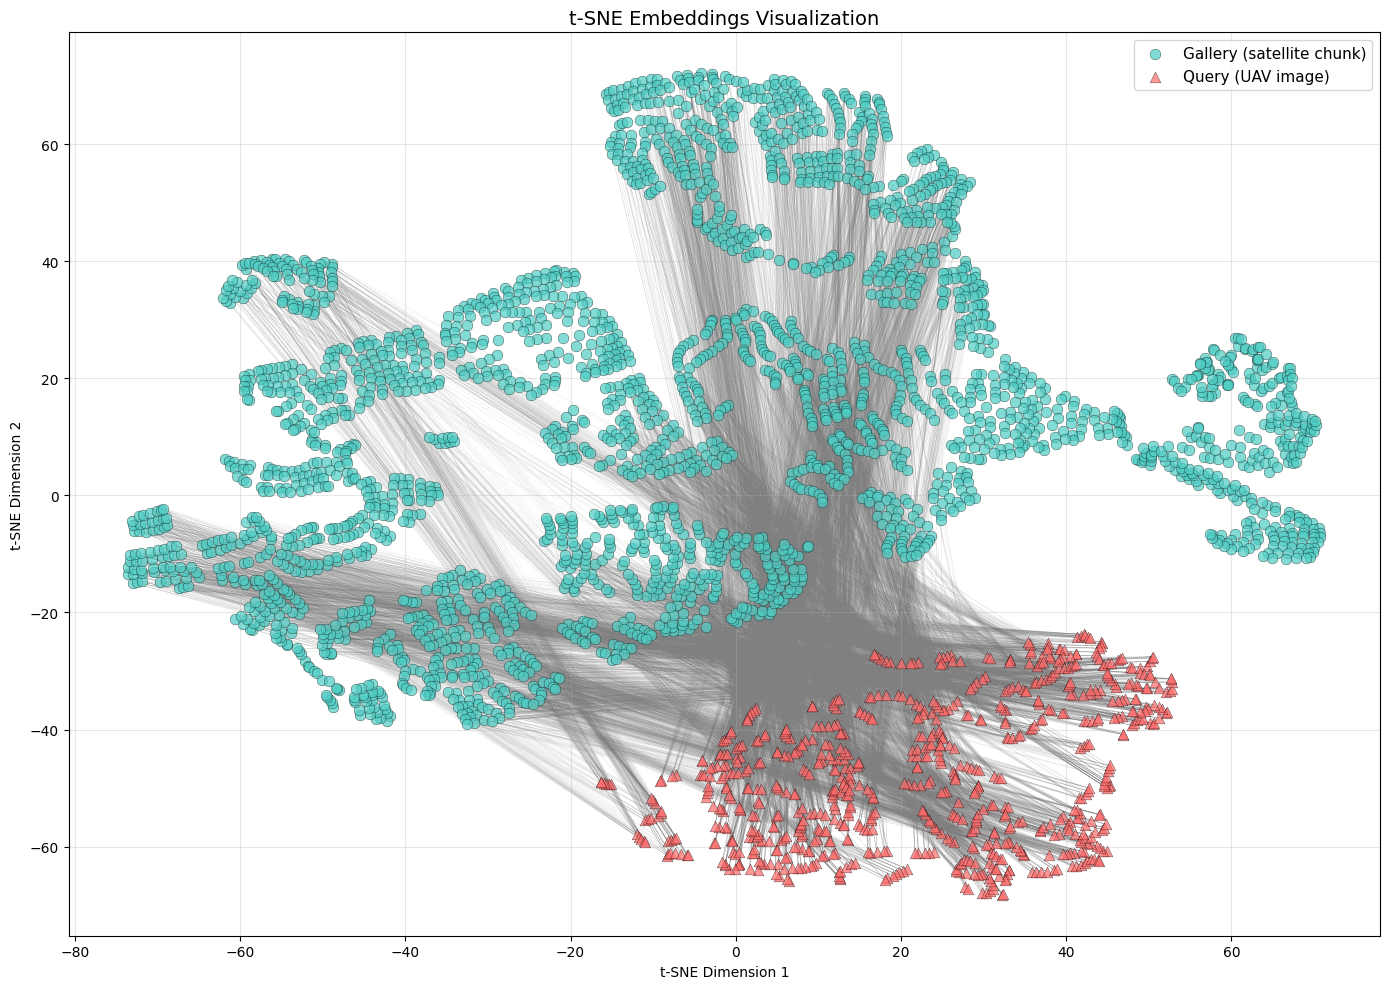

In [39]:
visualize_embeddings(gallery_embeddings, query_embeddings, ground_truth)